# Single-dataset: Differential Expression Analysis

This example demonstrates how to identify **differentially expressed genes** between
motif-positive and motif-negative anchor cells within a single spatial dataset.

After identifying an enriched motif, SpatialQuery can split anchor cells into two groups:
those surrounded by the motif (motif+) and those not (motif−). Comparing gene expression
between these groups reveals genes whose expression is associated with specific spatial contexts.

**Dataset:** seqFISH mouse organogenesis E8.5 embryo (17,806 cells × 351 genes)
**Key API:** `spatial_query.de_genes`

## Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd

from SpatialQuery import spatial_query

## Load Data & Initialize

In [4]:
DATA_DIR = "../data/mouse_organogenesis"

adata = ad.read_h5ad(f"{DATA_DIR}/embryo1.h5ad")
adata

AnnData object with n_obs × n_vars = 17806 × 351
    obs: 'embryo', 'pos', 'z', 'x_global', 'y_global', 'x_global_affine', 'y_global_affine', 'embryo_pos', 'embryo_pos_z', 'Area', 'UMAP1', 'UMAP2', 'celltype_mapped_refined', 'segmentation_vertices_x_global_affine', 'segmentation_vertices_y_global_affine'
    var: 'gene'
    uns: 'celltype_mapped_refined_colors'
    obsm: 'X_spatial', 'X_umap'

Inspect `adata.obsm` for spatial coordinates, `adata.obs` for cell type labels, and `adata.var` for gene names. Then set the corresponding column names below.

In [5]:
spatial_key = "X_spatial"
label_key = "celltype_mapped_refined"
feature_name = "gene"
dataset_name = "mouse_embryo1"

In [6]:
sp = spatial_query(
    adata=adata,
    dataset=dataset_name,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=True,
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 51.7200
build_gene_index is False. Using adata.X for gene expression analysis.
Log normalizing the expression data... If data is already log normalized, please set if_lognorm to False.


## Define Anchor Cell Type and Motif

We use **Gut tube** as the anchor and test the motif **[Splanchnic mesoderm, Endothelium]**.
First, test the enrichment and retrieve the cell IDs of motif-positive anchor cells using `motif_enrichment_dist`
with `return_cellID=True`.

> **Note:** In the single-dataset API, `return_cellID=True` adds `center_id` and `neighbor_id`
> columns directly to the returned DataFrame. The multi-FOV version returns a 3-tuple
> `(DataFrame, motif_id_dict, center_id_dict)` instead.

In [7]:
anchor_ct = "Gut tube"
motif = ["Splanchnic mesoderm", "Endothelium"]
max_dist = 8

motif_result = sp.motif_enrichment_dist(
    ct=anchor_ct,
    motifs=motif,
    max_dist=max_dist,
    return_cellID=True,
)

motif_result

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,neighbor_id,center_id,if_significant
0,Gut tube,"[Endothelium, Splanchnic mesoderm]",322,1464,3117,256.278109,0.000002,"[6151, 6163, 6168, 6182, 6188, 14381, 6199, 62...","[529, 536, 537, 547, 550, 4493, 4611, 4613, 46...",True


### Alternative: KNN-based Cell ID Retrieval

You can also retrieve motif-positive cell IDs using the KNN neighborhood definition instead of a fixed radius.

In [8]:
k = 50

motif_result_knn = sp.motif_enrichment_knn(
    ct=anchor_ct,
    motifs=motif,
    k=k,
    return_cellID=True,
)

motif_result_knn

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,neighbor_id,center_id,if_significant
0,Gut tube,"[Endothelium, Splanchnic mesoderm]",289,1464,2845,233.914411,0.000027,"[4471, 4482, 4497, 4510, 4516, 4526, 4535, 453...","[4493, 4619, 4621, 4623, 4654, 4656, 4662, 466...",True


## Split Anchor Cells into Motif+ and Motif− Groups

The `center_id` column contains the indices of motif-positive anchor cells. We derive
the motif-negative group as the complement.

In [9]:
center_id = motif_result["center_id"].iloc[0]
all_center_id = np.where(sp.labels == anchor_ct)[0]
non_center_id = np.setdiff1d(all_center_id, center_id)

print(f"Motif+ anchor cells: {len(center_id)}")
print(f"Motif− anchor cells: {len(non_center_id)}")

Motif+ anchor cells: 322
Motif− anchor cells: 1142


## Run Differential Expression Analysis

`de_genes` performs a statistical test (t-test, Wilcoxon, or Fisher's exact) to identify
genes differentially expressed between two groups of cells.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ind_group1` | Cell indices for group 1 (motif+) |
| `ind_group2` | Cell indices for group 2 (motif−) |
| `method` | Statistical test: `'t-test'`, `'wilcoxon'`, or `'fisher'` |
| `min_fraction` | Minimum fraction of cells expressing a gene (in either group) to include it |
| `alpha` | Significance threshold for adjusted p-values |

**Output columns:**

| Column | Description |
|--------|-------------|
| `gene` | Gene name |
| `proportion_1` / `proportion_2` | Fraction of cells expressing the gene in group 1/2 |
| `abs_difference` | Absolute difference in proportions |
| `log2fc` | Log2 fold change (group 1 vs group 2) |
| `p_value` | Raw p-value |
| `adj-pval` | FDR-adjusted p-value |
| `de_in` | Which group the gene is upregulated in (`group1` = motif+, `group2` = motif−) |

In [10]:
de_result = sp.de_genes(
    ind_group1=center_id,
    ind_group2=non_center_id,
    min_fraction=0.05,
    method="t-test",
    alpha=0.05,
)

print(f"Number of DE genes: {len(de_result)}")
de_result.head(10)

Testing 351 genes ...
Number of DE genes: 80


,gene,proportion_1,proportion_2,abs_difference,log2fc,p_value,adj-pval,de_in
0,Dkk1,0.111801,0.243433,0.131631,-1.586187,8.074493e-14,1.778115e-11,group2
1,Wnt5a,0.319876,0.472855,0.152979,-1.045780,1.013171e-13,1.778115e-11,group2
2,Osr1,0.652174,0.464974,0.187200,0.943958,2.715462e-12,3.177090e-10,group1
3,T,0.161491,0.260946,0.099455,-1.527118,6.675586e-12,5.857827e-10,group2
4,Meis1,0.503106,0.345009,0.158097,0.959926,1.492688e-09,1.047867e-07,group1
5,Otx2,0.180124,0.271454,0.091329,-1.065929,1.480319e-08,8.659869e-07,group2
6,Hoxb1,0.394410,0.270578,0.123832,1.148066,1.902122e-08,9.537782e-07,group1
7,Pitx1,0.173913,0.251313,0.077400,-1.158265,2.657183e-08,1.165839e-06,group2
8,Gata5,0.413043,0.280210,0.132833,1.014293,4.837701e-08,1.886703e-06,group1
9,Cdh2,0.267081,0.378284,0.111203,-0.793237,8.300411e-07,2.703245e-05,group2


## Visualize Top DE Genes

A volcano plot provides a quick overview of effect size (log2 fold change) vs significance.

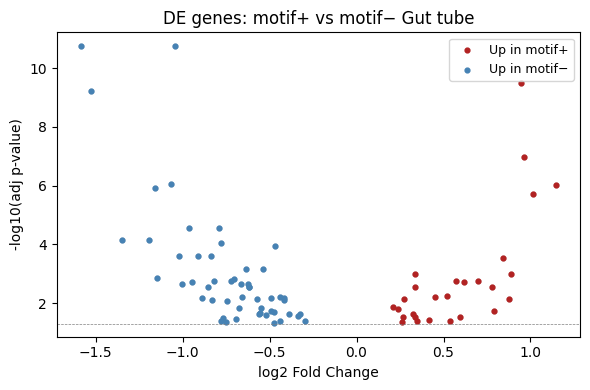

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

de = de_result.copy()
de["-log10(adj-pval)"] = -np.log10(de["adj-pval"].clip(lower=1e-300))

ax.scatter(
    de["log2fc"], de["-log10(adj-pval)"],
    c="grey", s=10, alpha=0.5,
)

# Highlight significant genes
sig = de[de["adj-pval"] < 0.05]
up = sig[sig["de_in"] == "group1"]  # motif+
down = sig[sig["de_in"] == "group2"]  # motif-
ax.scatter(up["log2fc"], up["-log10(adj-pval)"], c="firebrick", s=12, label="Up in motif+")
ax.scatter(down["log2fc"], down["-log10(adj-pval)"], c="steelblue", s=12, label="Up in motif−")

ax.axhline(-np.log10(0.05), color="grey", linestyle="--", linewidth=0.5)
ax.set_xlabel("log2 Fold Change")
ax.set_ylabel("-log10(adj p-value)")
ax.set_title(f"DE genes: motif+ vs motif− {anchor_ct}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()